## ISEL
### LEIM CSM TP2

Alunos: 
- Lucas Santos 52325
- Francisco Soares 52648

Turma 42D


In [7]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import math

## A)

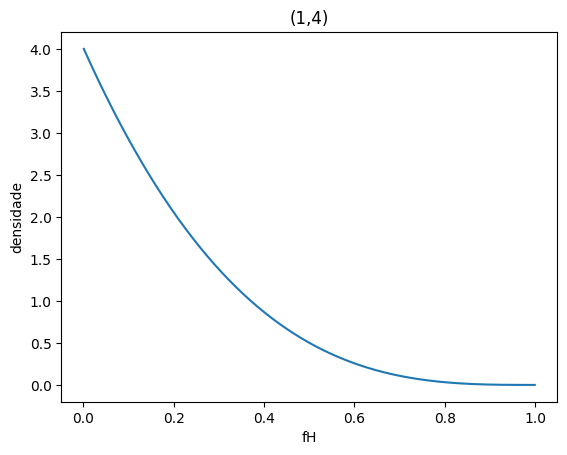

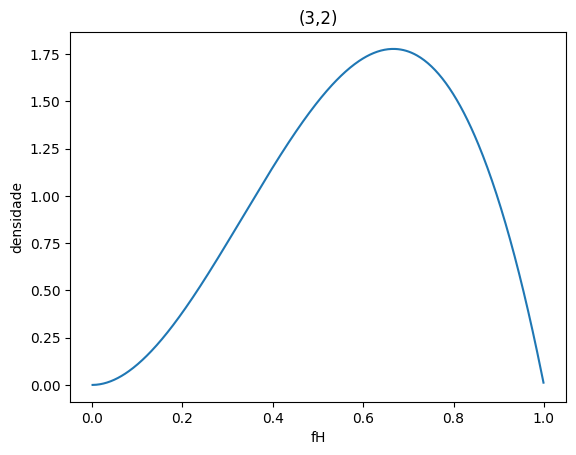

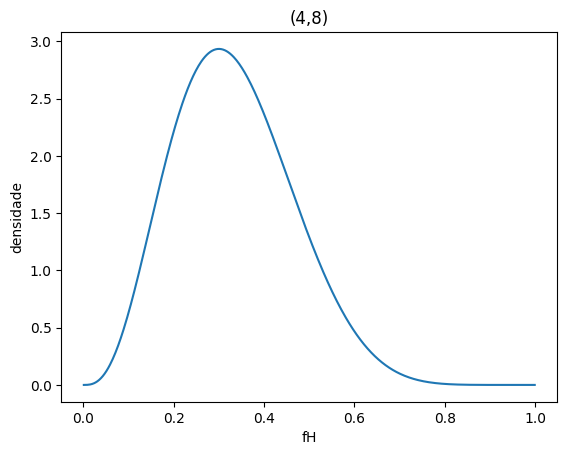

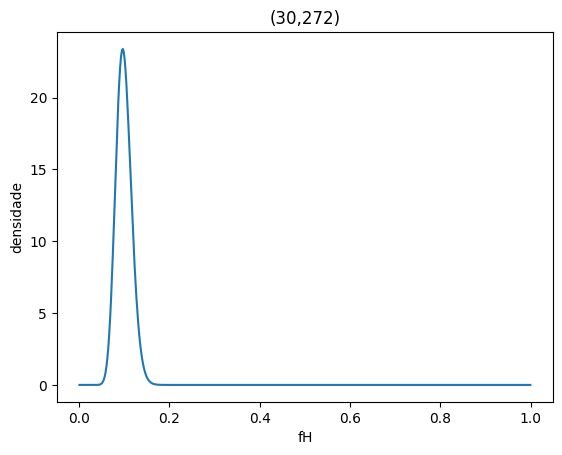

In [8]:
"""
Inferência Bayesiana para modelar o problema, 
tratando a probabilidade fH​ como uma variável aleatória.
"""


cases = [
    ("1)", 3, 0),
    ("2)", 3, 2),
    ("3)", 10, 3),
    ("4)", 300, 29),
]

# O 'x' representa os possíveis valores da probabilidade fH (de 0 a 1)
# Criamos 500 pontos para que o gráfico da curva fique suave
x = np.linspace(0.001, 0.999, 500)

for label, N, nH in cases:
    # TEORIA: Como o prior é uniforme, a distribuição posterior é uma Beta(a, b)
    # nH é o número de sucessos (caras), N-nH é o número de falhas (coroas)
    a = nH + 1      # Parâmetro alpha: reflete a "crença" nas caras
    b = N - nH + 1  # Parâmetro beta: reflete a "crença" nas coroas

# TEORIA: Esta é a fórmula do "caroço" da Distribuição Beta.
    # Ela combina o que sabíamos antes (prior) com os dados observados (verossimilhança).
    y = (x**(a - 1)) * ((1 - x)**(b - 1)) 

    #Normalização
    # TÉCNICO: A área sob uma curva de probabilidade deve ser sempre igual a 1.
    # Como a fórmula acima não está completa, dividimos pela integral (trapezoid) 
    # para "esticar" ou "encolher" a curva até que a área total seja 1
    y = y / np.trapezoid(y,x)

    plt.plot(x, y)
    plt.title(f"({a},{b})")
    plt.xlabel("fH")
    plt.ylabel("densidade")
    plt.show()

## B) 

In [9]:
#Probabilidade Condicional e Inferência.
#P(Algoritmo∩Nıˊvel)=P(Nıˊvel∣Algoritmo)×P(Algoritmo)
P_algoritmo = [0.4,0.35,0.25]


# matriz de Verossimilhança (P_NC_dado_algoritmo)

P_NC_dado_algoritmo = np.array([
#     A      B      C
    [0.05, 0.10, 0.20], # NC 0
    [0.15, 0.20, 0.25], # NC 1
    [0.40, 0.40, 0.30], # NC 2
    [0.30, 0.20, 0.15], # NC 3
    [0.10, 0.10, 0.10]  # NC 4
])

#Calcular a Distribuição Conjunta
#"Qual a chance de ser o algoritmo X E o nível Y?"
P_conjunta = P_NC_dado_algoritmo * P_algoritmo

#Distribuição Marginal dos níveis de compressão
P_marginal_NC = P_conjunta.sum(axis=1)

"""
pega o primeiro valor do array (0.40) e multiplica por toda a primeira coluna da matriz. 
Faz o mesmo com o segundo (0.35) para a segunda coluna, e assim por diante.

.sum(axis=1), está colapsando as colunas.

"""

print("Matriz Conjunta (Algoritmos nas colunas, NC nas linhas):")
print(P_conjunta)
print("\nDistribuição Marginal (Probabilidade total de cada NC):")
for i, prob in enumerate(P_marginal_NC):
    print(f"Nível {i}: {prob:.4f}")

Matriz Conjunta (Algoritmos nas colunas, NC nas linhas):
[[0.02   0.035  0.05  ]
 [0.06   0.07   0.0625]
 [0.16   0.14   0.075 ]
 [0.12   0.07   0.0375]
 [0.04   0.035  0.025 ]]

Distribuição Marginal (Probabilidade total de cada NC):
Nível 0: 0.1050
Nível 1: 0.1925
Nível 2: 0.3750
Nível 3: 0.2275
Nível 4: 0.1000


In [ ]:

#Teorema de Bayes
def classifica_algoritmo(NC):
    """
    Recebe o nível de compressão observado (0, 1, 2, 3 ou 4)
    e retorna as probabilidades de ter sido cada um dos algoritmos.
    """
    # Extraímos a linha correspondente ao NC da nossa matriz conjunta
    # Isso nos dá o P(Algoritmo ∩ NC) para cada um dos 3 algoritmos
    prob_conjunta_linha = P_conjunta[NC]
    
    # 2. Aplicamos o Teorema de Bayes:
    # P(Algoritmo | NC) = P(Algoritmo ∩ NC) / P(NC)
    # Onde P(NC) é a nossa Marginal que calculamos antes
    prob_posteriori = prob_conjunta_linha / P_marginal_NC[NC]
    
    return prob_posteriori

# --- Testando a função conforme o enunciado (NC = 3) ---
NC_observado = 3
resultado = classifica_algoritmo(NC_observado)

# Exibição bonita dos resultados
nomes_alg = ["A", "B", "C"]
print(f"Distribuição Posterior para NC = {NC_observado}:")
for i in range(len(nomes_alg)):
    print(f"P({nomes_alg[i]} | NC={NC_observado}) = {resultado[i]:.4f}")


Distribuição Posterior para NC = 3:
P(A | NC=3) = 0.5275
P(B | NC=3) = 0.3077
P(C | NC=3) = 0.1648


# B.c)

In [ ]:
# Prob de A, B e C
P_alg = np.array([0.4, 0.35, 0.25])  #[A, B, C]

# Probabilidades: P(NC | algoritmo)
# linhas: NC = 0, 1, 2, 3 e 4
# Colunas: A, B e C
NC = np.array([
    [0.05, 0.10, 0.20],  # NC: 0
    [0.15, 0.20, 0.25],  # NC: 1
    [0.40, 0.40, 0.30],  # NC: 2
    [0.30, 0.20, 0.15],  # NC: 3
    [0.10, 0.10, 0.10],  # NC: 4
])

alg_names = ['A', 'B', 'C']

# Maxima verosimilhança: P(NC | alg)

ml_per_alg = np.argmax(NC, axis=0)

print("Máxima Verosimilhança (ML):")
for i, nc in enumerate(ml_per_alg):
    print(f"Algoritmo {alg_names[i]}: NC = {nc}")

# Map

# P(NC, alg) = P(NC | alg) * P(alg)
P_NC_alg = NC * P_alg

# P(NC)
P_NC = P_NC_alg.sum(axis=1)

# P(alg | NC)
P_alg_condicional_NC = P_NC_alg / P_NC[:, None]

map_per_nc = np.argmax(P_alg_condicional_NC, axis=1)

print("\nMAP (algoritmo mais provável para cada NC):")
for nc, alg_idx in enumerate(map_per_nc):
    print(f"NC = {nc}: {alg_names[alg_idx]}")

# B.d

In [ ]:
niveis = np.array([0, 1, 2, 3, 4])

for i, nome in enumerate(nomes_alg):
    # Pegamos a probabilidade condicional do algoritmo atual (coluna i)
    # Importante: usamos P_NC_dado_algoritmo pois queremos o comportamento DO algoritmo
    p_condicional = P_NC_dado_algoritmo[:, i]
    
    #  Valor Esperado (Média)
    # E[NC] = sum( NC * P(NC|Alg) )
    valor_esperado = np.sum(niveis * p_condicional)
    
    #  Variância
    # Var(NC) = E[NC^2] - (E[NC])^2
    valor_esperado_quadrado = np.sum((niveis**2) * p_condicional)
    variancia = valor_esperado_quadrado - (valor_esperado**2)
    
    print(f"--- Algoritmo {nome} ---")
    print(f"Valor Esperado (Média): {valor_esperado:.4f}")
    print(f"Variância: {variancia:.4f}\n")

--- Algoritmo A ---
Valor Esperado (Média): 2.2500
Variância: 0.9875

--- Algoritmo B ---
Valor Esperado (Média): 2.0000
Variância: 1.2000

--- Algoritmo C ---
Valor Esperado (Média): 1.7000
Variância: 1.5100



## C)

In [19]:
def plot_h_delta(N, p1=0.1, cor='blue'):
    p0 = 1 - p1
    probs_totais = []

    # Gerar as probabilidades
    for r in range(N + 1):
        p_sequencia = (p0**(N - r)) * (p1**r) #P (x) = p0**(N −r(x)) p1**r(x)
        quantidade = math.comb(N, r)
        for i in range(quantidade):
            probs_totais.append(p_sequencia)

    #  Ordenar
    probs_totais.sort(reverse=True)

    # Calcular para vários deltas
    deltas = np.linspace(0, 1, 200)
    eixo_y_bits = []

    for d in deltas:
        prob_alvo = 1 - d
        soma_atual = 0
        contagem = 0
        
        for p in probs_totais:
            if soma_atual < prob_alvo:
                soma_atual += p
                contagem += 1
            else:
                break
        
        # Guardamos o log2 do tamanho do conjunto
        eixo_y_bits.append(np.log2(max(1, contagem)))

    # 4. Adicionar ao gráfico atual (sem dar plt.show ainda)
    plt.step(deltas, eixo_y_bits, where='post', label=f'N = {N}', color=cor)
    

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_174435/3433794925.py:9: SyntaxWarning: invalid escape sequence '\d'
  plt.title('Comparação de $H_\delta(X^N)$ para diferentes $N$')
/tmp/ipykernel_174435/3433794925.py:10: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('Erro tolerado ($\delta$)')


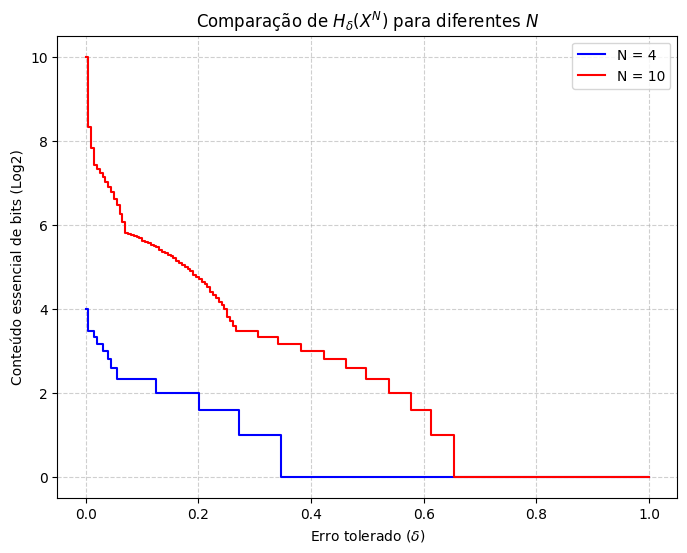

In [20]:
plt.figure(figsize=(8, 6))

# Chamando a função para diferentes valores de N
plot_h_delta(N=4,  cor='blue')
plot_h_delta(N=10, cor='red')


# Configurações do gráfico final
plt.title('Comparação de $H_\delta(X^N)$ para diferentes $N$')
plt.xlabel('Erro tolerado ($\delta$)')
plt.ylabel('Conteúdo essencial de bits (Log2)')
plt.legend() # Mostra a legenda com os valores de N
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()